# Práctica computacional
## Semana 4 — Dinámica de Sistemas I: Stocks, Flujos y el Ciclo de Inversión
## Notebook Interactivo · Systems Analytics — MISE

In [1]:
import sys; sys.path.insert(0, '.')
from mise_utils import viz, dynamics, energy_data
from mise_utils.viz import COLORS
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
viz.apply_mise_style()

### Nivel 1 **Nivel 1 —** (Intuición sin energía)

**4.1 La bañera más famosa del mundo**

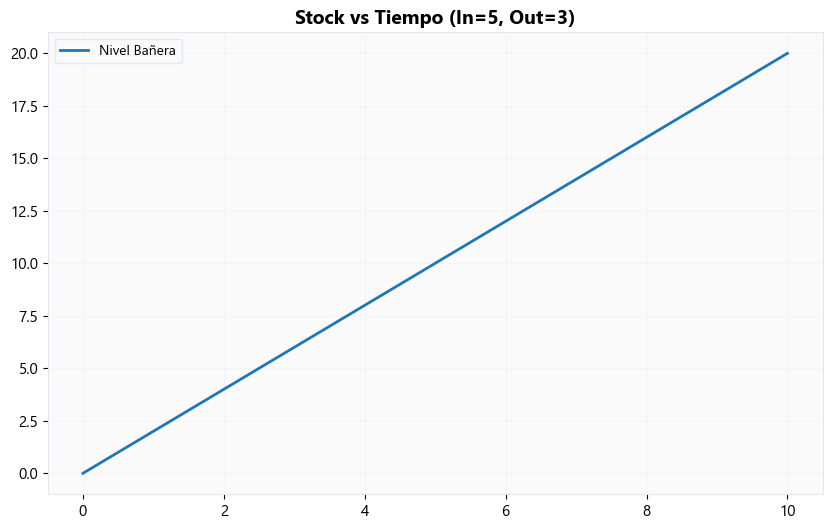

In [2]:
def modelo_banera(t, y, flujo_in, flujo_out):
    return [flujo_in - flujo_out]

t_span = (0, 10)
t_eval = np.linspace(0, 10, 100)
sol = solve_ivp(modelo_banera, t_span, [0], args=(5, 3), t_eval=t_eval)

plt.plot(sol.t, sol.y[0], label='Nivel Bañera')
plt.legend()
plt.title('Stock vs Tiempo (In=5, Out=3)')
plt.show()

****Insight:** Insight 4.1:** Mientras el flujo de entrada sea mayor al de salida, el stock crecerá linealmente. La dinámica simple de acumulación.

**4.2 Crecimiento vs estabilización**

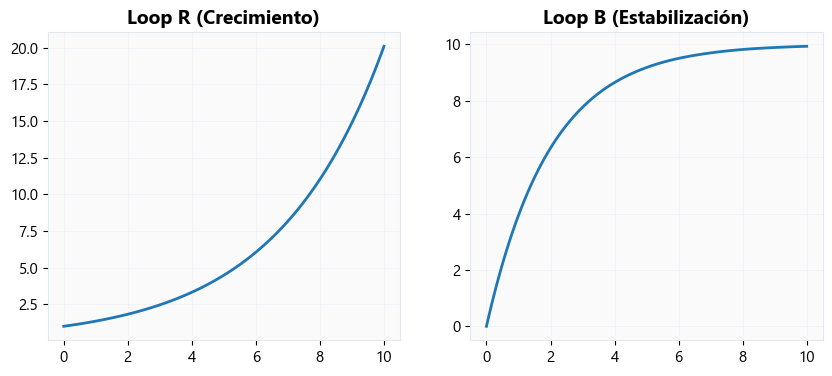

In [3]:
def loop_R(t, y, r): return [r * y[0]]
def loop_B(t, y, k, obj): return [k * (obj - y[0])]

sol_R = solve_ivp(loop_R, (0, 10), [1], args=(0.3,), t_eval=t_eval)
sol_B = solve_ivp(loop_B, (0, 10), [0], args=(0.5, 10), t_eval=t_eval)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))
ax1.plot(sol_R.t, sol_R.y[0]); ax1.set_title('Loop R (Crecimiento)')
ax2.plot(sol_B.t, sol_B.y[0]); ax2.set_title('Loop B (Estabilización)')
plt.show()

****Insight:** Insight 4.2:** El Loop R genera curvas exponenciales. El Loop B genera curvas de búsqueda de objetivo asintóticas.

**4.3 ¿Por qué todo oscila?**

<Axes: title={'center': 'La ducha con retardo: oscilaciones por delay de 3.0s'}, xlabel='Tiempo (s)', ylabel='Temperatura (°C)'>

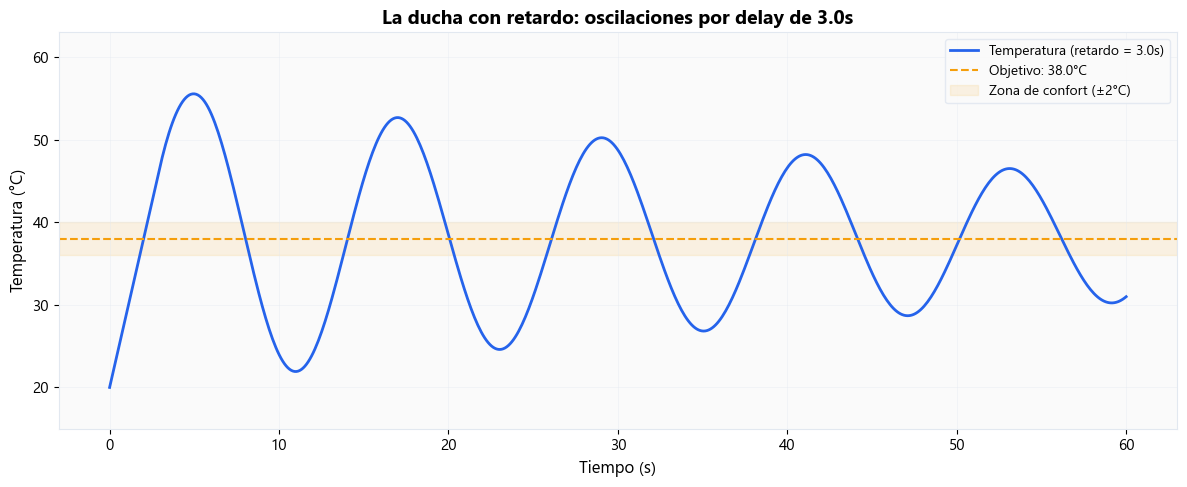

In [4]:
# Slider: delay from 0 to 6
delay = 3
dynamics.plot_modelo_ducha(delay=delay)

****Insight:** Insight 4.3:** Un retardo en la percepción y acción convierte un ciclo estable de balance (Loop B) en un sistema oscilatorio que sobre-corrige.

**4.4 Beer Game simplificado**

In [5]:
dynamics.modelo_beer_game(delay_entrega=4, delay_percepcion=2)

,t,demanda_consumidor,inventario_Tienda,inventario_Distribuidor,inventario_Fábrica,pedidos_Tienda,pedidos_Distribuidor,pedidos_Fábrica
0,0,101.523585,200.000000,200.000000,200.000000,0.000000,0.000000,0.000000
1,1,94.800079,205.199921,300.000000,300.000000,99.963609,70.000000,70.000000
2,2,103.752256,201.447665,300.036391,330.000000,101.089286,69.989083,61.000000
3,3,104.702824,196.744841,298.947105,360.010917,95.776627,70.279478,21.996725
4,4,90.244824,206.500017,303.170478,389.731439,101.802251,70.138143,13.069651
5,5,93.489102,212.974524,271.368227,389.593297,100.810466,74.366159,13.401489
6,6,100.639202,213.424608,240.546843,376.227137,86.217442,89.638198,17.270002
7,7,98.418787,210.782448,224.608879,308.585664,90.254368,93.427803,41.790460
8,8,99.915994,212.668705,204.492654,228.227512,96.838591,84.869646,81.169944
9,9,95.734780,217.744391,182.020222,156.759356,93.095470,95.648301,106.399996


****Insight:** Insight 4.4:** El efecto látigo (Bullwhip effect) demuestra cómo pequeños cambios en el inicio de la cadena se amplifican masivamente debido a los retardos.

### Nivel 2 **Nivel 2 —** (Aplicaciones en Energía)

**4.5 El ciclo inversión-capacidad colombiano**

(<Figure size 1400x1000 with 4 Axes>,
 array([[<Axes: title={'center': 'Capacidad vs Demanda'}, ylabel='MW'>,
         <Axes: title={'center': 'Precio de Bolsa'}, ylabel='COP/kWh'>],
        [<Axes: title={'center': 'Pipeline de Proyectos'}, xlabel='Año', ylabel='MW en construcción'>,
         <Axes: title={'center': 'Margen de Reserva'}, xlabel='Año', ylabel='Margen de reserva (%)'>]],
       dtype=object))

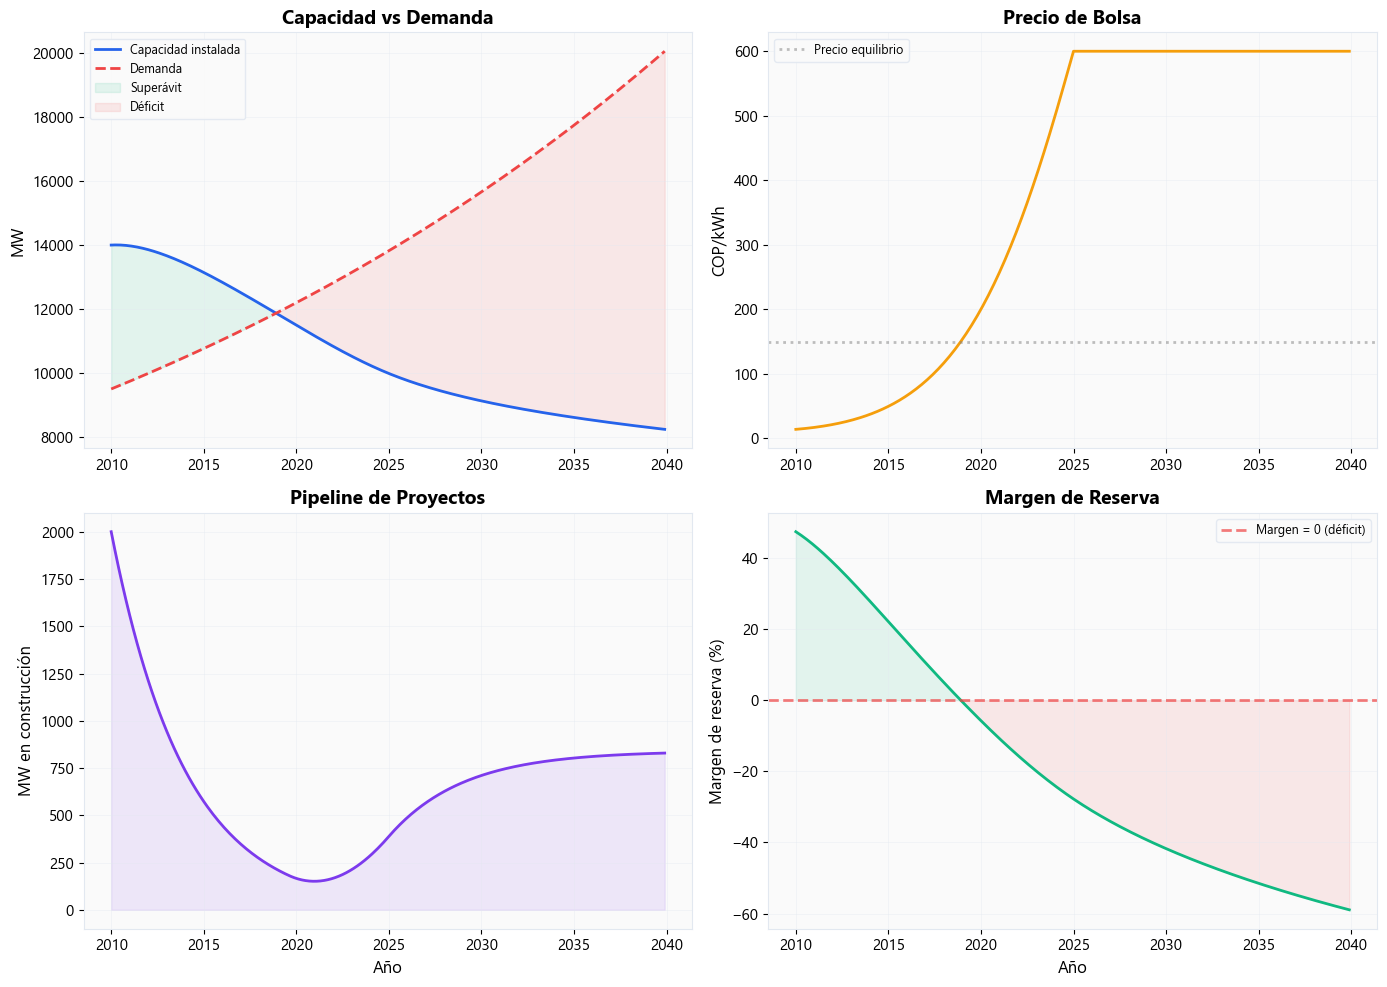

In [6]:
# Las ecuaciones del ciclo de inversion-capacidad
# (ya implementadas en dynamics.modelo_inversion_capacidad)
def ciclo_inversion(t, y, params):
    cap, pipeline, demanda = y
    gap = (demanda - cap) / max(demanda, 1)
    precio = params['precio_base'] * np.exp(params['k_precio'] * gap)
    
    inicio = params['inversion_base'] * (precio / params['precio_base'])
    puesta = pipeline / params['delay_construccion']
    retiro = cap / params['vida_util']
    crec = demanda * params['tasa_crecimiento']
    
    return [puesta - retiro, inicio - puesta, crec]

# Simular y visualizar el ciclo completo
df_ciclo = dynamics.modelo_inversion_capacidad()
dynamics.plot_ciclo_inversion(df_ciclo)


****Insight:** Insight 4.5:** El sector exhibe oscilaciones crónicas de alrededor de 8-10 años. Alta demanda detona precios altos, atrayendo sobre-inversión que luego colapsa el mercado.

**4.6 ¿Qué pasa si duplicamos el retardo?**

(<Figure size 1400x1000 with 4 Axes>,
 array([[<Axes: title={'center': 'Capacidad vs Demanda'}, ylabel='MW'>,
         <Axes: title={'center': 'Precio de Bolsa'}, ylabel='COP/kWh'>],
        [<Axes: title={'center': 'Pipeline de Proyectos'}, xlabel='Año', ylabel='MW en construcción'>,
         <Axes: title={'center': 'Margen de Reserva'}, xlabel='Año', ylabel='Margen de reserva (%)'>]],
       dtype=object))

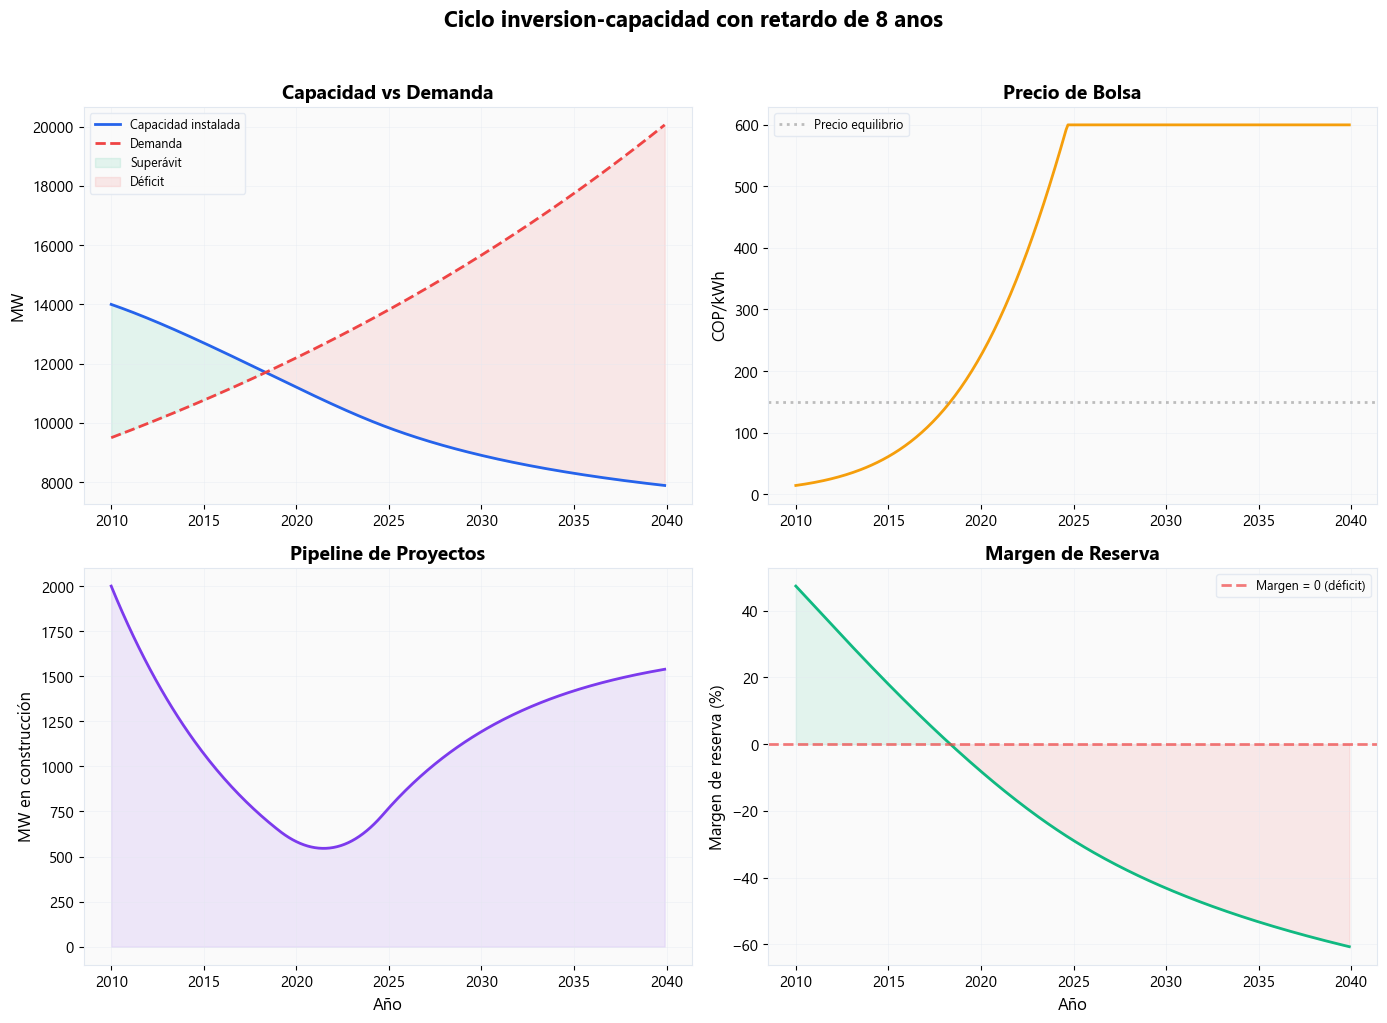

In [7]:
# Efecto de un retardo largo de construccion
df_largo = dynamics.modelo_inversion_capacidad(
    params={'delay_construccion': 8}
)
dynamics.plot_ciclo_inversion(
    df_largo,
    titulo='Ciclo inversion-capacidad con retardo de 8 anos'
)

****Insight:** Insight 4.6:** Aumentar el tiempo de construcción de 4 a 8 años (ej. demoras ambientales) incrementa la amplitud de las oscilaciones y el riesgo de apagones.

**4.7 Precio lineal vs no-lineal**

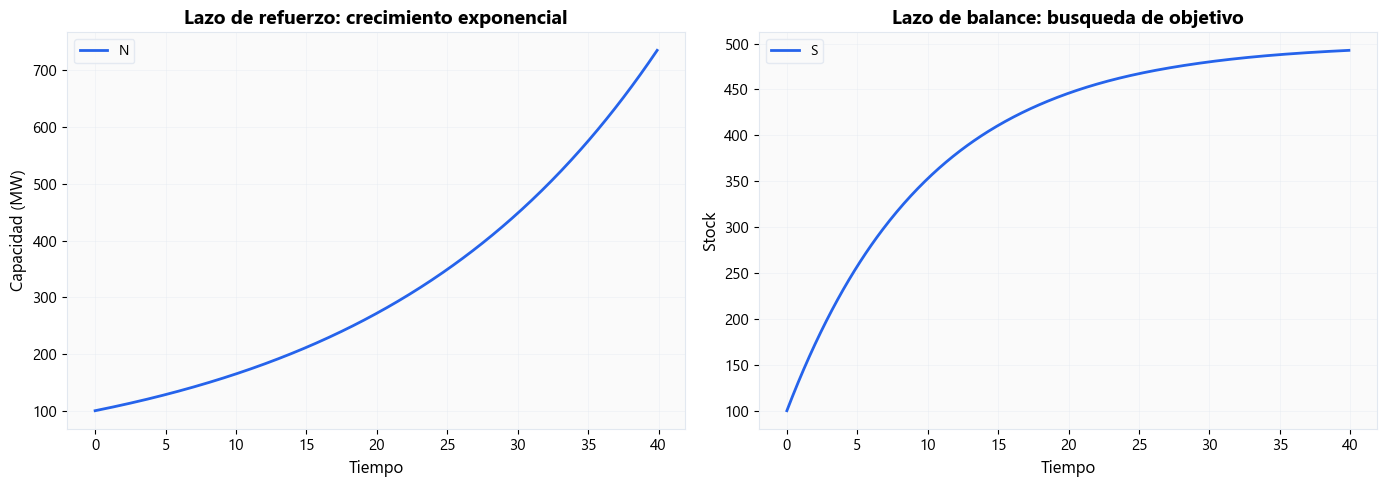

In [8]:
# Comportamiento lineal vs exponencial: por que importa la estructura
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Crecimiento exponencial (lazo de refuerzo)
res_exp = dynamics.modelo_crecimiento_exponencial(r=0.05, N0=100, T=40)
dynamics.plot_modelo_basico(
    res_exp, ['N'],
    titulo='Lazo de refuerzo: crecimiento exponencial',
    ylabel='Capacidad (MW)', ax=axes[0]
)

# Busqueda de objetivo (lazo de balance)
res_obj = dynamics.modelo_busqueda_objetivo(k=0.1, objetivo=500, S0=100, T=40)
dynamics.plot_modelo_basico(
    res_obj, ['S'],
    titulo='Lazo de balance: busqueda de objetivo',
    ylabel='Stock', ax=axes[1]
)

plt.tight_layout()

****Insight:** Insight 4.7:** Las funciones de precio de escasez (no-lineales) amplifican la respuesta del inversiónista, agravando las oscilaciones si no hay regulación estabilizadora.

### Nivel 3 **Nivel 3 —** (Profesional)

**4.8 Arquetipos Sistémicos**
- **Limits to Growth:** La expansión del sector eléctrico colombiano choca periódicamente con límites (agua, capacidad de red, licencias). El crecimiento incentiva a buscar capacidad, pero los retardos exacerban los frenazos forzosos.
- **Fixes that Fail:** Intentar limitar precios transitoriamente durante sequías para proteger la inflación desincentiva la inversión de largo plazo, incubando la próxima escasez.

**4.9 Puente a Modelado Basado en Agentes (ABM)**
La dinámica de sistemas asume agentes homogéneos agregados (una sola "bañera" de capacidad). En el mundo real, las diferentes empresas tienen diferentes apetitos de riesgo. En etapas futuras, exploraremos ABM para modelar estas heterogeneidades.

### Cierre — Resumen y Previa de S5

Hemos construido un modelo endógeno capaz de replicar las oscilaciones que azotan los mercados eléctricos liberalizados. Los retardos y las señales no lineales de precios generan sobre-correcciones (ciclos de boom y caída).

*"Sabemos construir el modelo. ¿Pero qué pasa si cambiamos las reglas?"*

En la **Semana 5**, introduciremos instrumentos regulatorios virtuales (como el Cargo por Confiabilidad o las subastas a largo plazo) en este mismo código, evaluando su eficacia para amortiguar el sistema.